### Remaining Questions

- a) Histogram / line / scatterplot?
- b) Which version: best model per condition, or consistent model that is best on average?

## --> Figure 1A

Files needed: Individual csv files

NOTE: This will plot individual RMSE values per tile. The average of these individual values is different than the overall RMSE value (since RMSE cannot be averaged).


- Plotting RMSE vs. frequency of the entire test set

- The entire test set contains NUM_SEEDS * (NUM_CON * R + NUM_CON * S) = 24 individual csv files
    - R = test data from the Rockies
    - S = test data from the Swiss Alps
    - NUM_CON = (NCL = clear, CL = cloudy, NHR = no-hr, and CLNHR = cloudy-no-hr test data)
    - NUM_SEEDS = 3

Two versions:
1) Predicted with the best average model (clouds-trained)
2) Predicted with the best model per condition

In [ ]:
# Pseudo-Code
# 1) Combine all csv files into one, take care of the individual names
# 2) Plot RMSE historgram, with points for the selected samples

### File Preprocessing

In [70]:
import os
import pandas as pd

folder_v1 = "csv/version_best"
combined_df_v1 = pd.DataFrame()

for file in os.listdir(folder_v1):
    if file.endswith(".csv"):
        region = file.split("_")[2]
        checkpoint_name = file.split("_")[-1].split(".")[0]
        file_path = os.path.join(folder_v1, file)
        df = pd.read_csv(file_path)
        df["region"] = region
        df["checkpoint_name"] = checkpoint_name
        combined_df_v1 = pd.concat([combined_df_v1, df], ignore_index=True)

        # then, remove the last row of the dataframe
        df = df[:-1]

combined_df_v1.to_csv("combined_results_best.csv", index=False)

In [71]:
import os
import pandas as pd

folder_v2 = "csv/version_clouds"
combined_df_v2 = pd.DataFrame()

for file in os.listdir(folder_v2):
    if file.endswith(".csv"):
        region = file.split("_")[2]
        checkpoint_name = file.split("_")[-1].split(".")[0]
        file_path = os.path.join(folder_v2, file)
        df = pd.read_csv(file_path)
        df["region"] = region
        df["checkpoint_name"] = checkpoint_name
        combined_df_v2 = pd.concat([combined_df_v2, df], ignore_index=True)

        # then, remove the last row of the dataframe
        df = df[:-1]

combined_df_v2.to_csv("combined_results_clouds.csv", index=False)

### Plotting Version 1

Text(0, 0.5, 'Frequency')

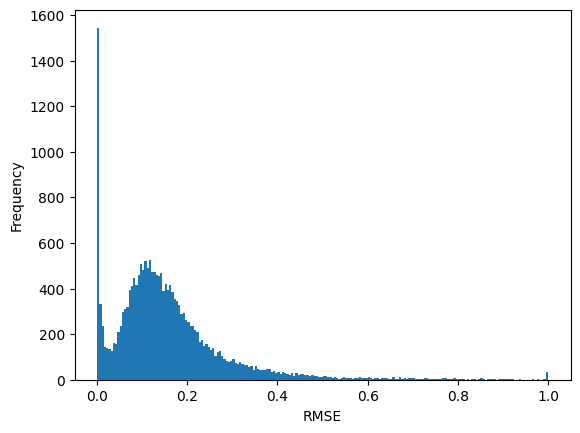

In [ ]:
import matplotlib.pyplot as plt

# plot histogram of RMSE values
plt.hist(combined_df_v1["rmse"], bins=200)
plt.xlabel("RMSE")
plt.ylabel("Frequency")

### Plotting Version 2

Text(0, 0.5, 'Frequency')

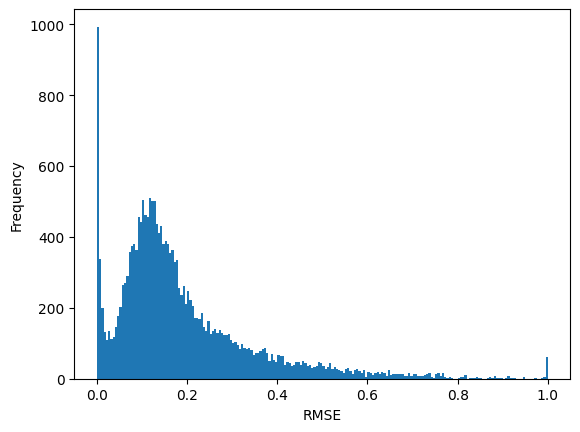

In [ ]:
import matplotlib.pyplot as plt

# plot histogram of RMSE values
counts, bins, patches = plt.hist(combined_df_v2["rmse"], bins=200)
plt.xlabel("RMSE")
plt.ylabel("Frequency")

In [69]:
# print the overall mean RMSE value for the combined dataframe
print("Overall mean RMSE value for version_clouds:", combined_df_v1["rmse"].mean())

edges = [
    [0.00, 0.01],
    [0.10, 0.11],
    [0.20, 0.21],
    [0.60, 0.61],
    [0.99, 1.00],
]

for i in range(len(edges)):
    lower_edge = edges[i][0]
    upper_edge = edges[i][1]

    # Filter data: include lower bound, exclude upper (except for the last bin)
    if i == len(bins) - 2:
        samples_in_bin = combined_df_v1[(combined_df_v1["rmse"] >= lower_edge) & (combined_df_v1["rmse"] <= upper_edge)]
    else:
        samples_in_bin = combined_df_v1[(combined_df_v1["rmse"] >= lower_edge) & (combined_df_v1["rmse"] < upper_edge)]

    # print randomly selected sample from the bin
    if not samples_in_bin.empty:
        random_sample = samples_in_bin.sample(n=1)
        print(f"Random sample from bin {lower_edge:.2f} - {upper_edge:.2f}:")
        print(random_sample[["region", "checkpoint_name", "rmse"]])

Overall mean RMSE value for version_clouds: 0.156182087333011
Random sample from bin 0.00 - 0.01:
            region checkpoint_name      rmse
11861  switzerland        qtqv5sml  0.000493
Random sample from bin 0.10 - 0.11:
       region checkpoint_name     rmse
6662  rockies        w91nkzn3  0.10408
Random sample from bin 0.20 - 0.21:
       region checkpoint_name      rmse
5633  rockies        jw3xlo27  0.207349
Random sample from bin 0.60 - 0.61:
            region checkpoint_name      rmse
19870  switzerland        pj7k8gxe  0.608837
Random sample from bin 0.99 - 1.00:
       region checkpoint_name      rmse
5144  rockies        0p61oiba  0.998256


In [ ]:
# print the overall mean RMSE value for the combined dataframe
print("Overall mean RMSE value for version_clouds:", combined_df_v2["rmse"].mean())

edges = [
    [0.00, 0.01],
    [0.10, 0.11],
    [0.20, 0.21],
    [0.60, 0.61],
    [0.99, 1.00],
]

for i in range(len(edges)):
    lower_edge = edges[i][0]
    upper_edge = edges[i][1]

    # Filter data: include lower bound, exclude upper (except for the last bin)
    if i == len(bins) - 2:
        samples_in_bin = combined_df_v2[(combined_df_v2["rmse"] >= lower_edge) & (combined_df_v2["rmse"] <= upper_edge)]
    else:
        samples_in_bin = combined_df_v2[(combined_df_v2["rmse"] >= lower_edge) & (combined_df_v2["rmse"] < upper_edge)]

    # print randomly selected sample from the bin
    if not samples_in_bin.empty:
        random_sample = samples_in_bin.sample(n=1)
        print(f"Random sample from bin {lower_edge:.2f} - {upper_edge:.2f}:")
        print(random_sample[["region", "checkpoint_name", "rmse"]])

Overall mean RMSE value for version_best: 0.156182087333011
Overall mean RMSE value for version_clouds: 0.18912358323860065
Random sample from bin 0.00 - 0.01:
       region checkpoint_name      rmse
3071  rockies        1y17j4tq  0.002797
Random sample from bin 0.10 - 0.11:
       region checkpoint_name     rmse
6144  rockies        5pu8e3vn  0.10027
Random sample from bin 0.20 - 0.21:
            region checkpoint_name      rmse
13712  switzerland        5pu8e3vn  0.204983
Random sample from bin 0.60 - 0.61:
            region checkpoint_name      rmse
16465  switzerland        5pu8e3vn  0.603382
Random sample from bin 0.99 - 1.00:
       region checkpoint_name      rmse
5939  rockies        5pu8e3vn  0.999981


## Figure 1B

- Files needed: input, labels, predictions

- Plot individual FSC input, label, predictions based from different parts of the RMSE distribution (RGB, target, prediction, error)
- Make sure to also plot some images with cloud simulation
- Write Figure caption

In [ ]:
# Pseudo-Code
# 1) From the combined csv file, extract a few regularly spaced rows (e.g. every 10th row)
# 2) Get the filename, the model condition, and the model name from the extracted rows
# 3) Retrieve the input, prediction and target data from the extracted rows

## Figure 2

- Files needed: inputs, predictions

- See if there are temporally close targets from the same location
- Predict these with gap-filling
- Otherwise predict 10 random samples with gap-filling and choose one

## Figure 3

- Files needed: inputs, predictions

- Stitch 5 km x 5 km and find corresponding GlobalSnowpack prediction
- Also stitch the RGB input images

## Figure 4

- TO-DO: Change the RMSE computation (overall RMSE, not averaged)

- Files needed: Test set summaries

- RMSE comparison SnowGalileo and baseline methods
- Error bar showing the different model seeds
- Include all conditions (clear, cloudy, no-hr, no-hr-clouds)

Two versions:
1) Switzerland and Rockies distinct bars, cloudy model
2) Switzerland and Rockies distinct bars, best model per condition

## Figure 5

- TO-DO: How to bring together the pixel-wise models

- Files needed: input, predictions, labels for all models

- Qualitative comparison of the different models, with RMSE values

## Figure 6

- Individual files .csv

- Like Figure 1A but Rockies and Switzerland separately
- Scatter plot with mean line instead of mean line only

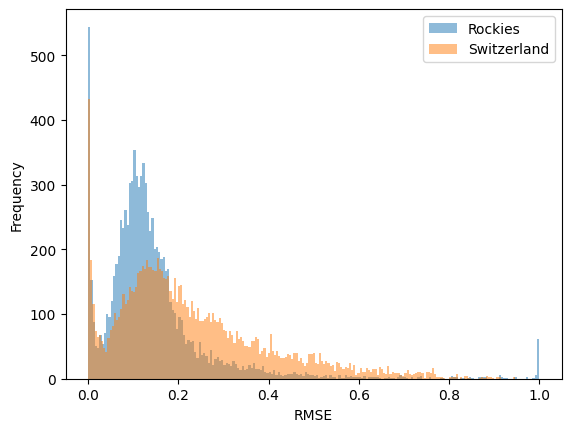

In [76]:
rockies = combined_df_v2[combined_df_v2["region"] == "rockies"]
switzerland = combined_df_v2[combined_df_v2["region"] == "switzerland"]

# plot histogram of RMSE values, grouped by region
plt.hist(rockies["rmse"], bins=200, label="Rockies", alpha=0.5)
plt.hist(switzerland["rmse"], bins=200, label="Switzerland", alpha=0.5)
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.legend()

## --> Figure 7

- Files needed: Individual tiles .csv

- (For Switzerland and maybe Rockies): Seasonal dependency

## --> Figure 8

- TO-DO: run with different amounts of cloud coverage in test set

- Files needed: Test set summaries, input and prediction tiles for clouds

- A): Performance under different amount of cloudy conditions, for rockies only
- B): Qualitative plots of the cloudy conditions, for rockies only

## OTHERS

- Best / worst samples Switzerland / Rockies (5 samples)
- Optionally: vegetation cover, HR cover